# t-SNE on raw trajectories

In [1]:
import numpy as np
data = np.load("../../../simulated_data/001-gridrobot/data/gridrobot_1960.npz")
all_trajs = data["trajs"]
all_feats = data["features"]

------ Agent MDP ------
num X :  5
num Y :  5
obstacles :  0
-----------------------


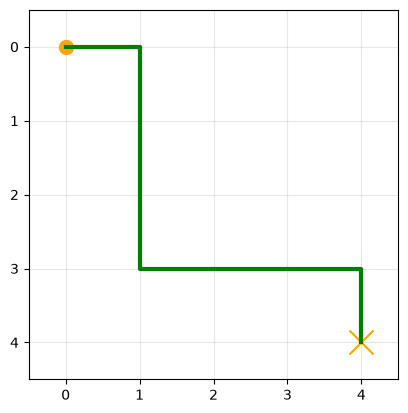

In [2]:
import sys
sys.path.insert(0, '../../../simulated_data/001-gridrobot/')
from gridrobot import Gridrobot
    
config = {
    "X": 5,
    "Y": 5,
    "obstacles": [],
    "starts": [[0, 0], [0, 4], [4, 0], [4, 4]],
    "goals": [[4, 4], [4, 0], [0, 4], [0, 0]],
    "features": ["computer_dist", "joint_up"],
    "thetas": [[ -10.0, -10.0 ],
              [ 0.0, -10.0 ],
              [ 10.0, -10.0 ],
              [ -10.0, 0.0 ],
              [ 10.0, 0.0 ],
              [ -10.0, 10.0 ],
              [ 0.0, 10.0 ],
              [ 10.0, 10.0 ]
    ],
    "beta": 10.0,
    "feature_scaling": "normalize",
    "train_test_split": 0.8
}
env = Gridrobot(config["X"], config["Y"], config["obstacles"], config["starts"], config["goals"])
env.visualize_one_traj(all_trajs[0])

In [11]:
import plotly.graph_objects as go
from ipywidgets import Output, HBox
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def fancy_scatter(data_2d, title, x_label=None, y_label=None):
    # # t-SNE (same as before) — order is preserved, so row i <-> all_trajs[i]
    # trajs_t_sne = TSNE(n_components=2, random_state=0).fit_transform(all_trajs)

    # scatter as a FigureWidget so we can attach a hover callback
    scatter = go.FigureWidget(
        data=[go.Scatter(
            x=data_2d[:, 0],
            y=data_2d[:, 1],
            mode="markers",
            marker=dict(size=8, opacity=0.7),
            customdata=list(range(len(all_trajs))),
            hovertemplate="traj %{customdata}<extra></extra>",
        )]
    )
    scatter.update_layout(
        width=500, 
        height=500, 
        title=title)
    if x_label:
        scatter.update_layout(
            xaxis_title=x_label
            )
    if y_label:
        scatter.update_layout(
            yaxis_title=y_label
            )

    # side panel where the trajectory gets drawn
    out = Output()

    def show_traj(trace, points, state):
        if not points.point_inds:
            return
        idx = points.point_inds[0]
        with out:
            clear_output(wait=True)          # replace the previous trajectory
            env.visualize_one_traj(all_trajs[idx])
            plt.show()

    scatter.data[0].on_hover(show_traj)

    display(HBox([scatter, out]))  # scatter on the left, trajectory on the right

In [12]:
t_sne = TSNE(
    n_components=2,
    perplexity=30,
    init="random",
    max_iter=250,
    random_state=0,
)
trajs_t_sne = t_sne.fit_transform(all_trajs)
fancy_scatter(trajs_t_sne, "raw traj t-SNE")

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

4 distinct clusters, 1 per (start point, end point) pair (since trajectory always goes from one corner to the opposite corner)

# 

# feature vectors

In [10]:
fancy_scatter(all_feats, "2D ground truth feature vectors", x_label="laptop", y_label="upright")

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

# sirl embeds

In [17]:
import torch
from sirl import load_sirl

def sirl(trajs, latent_dim):
    """
    take frozen SIRL encoder from expt 003
    load from sirl_ckpts (copied relevant ckpts into this dir)
    """
    ckpt_path = f"../sirl_ckpts/sirl_dim{latent_dim}_seed0.pth"
    print(f"loading ckpt {ckpt_path}")
    model = load_sirl(ckpt_path)
    model.eval()
    embeds = model(torch.tensor(trajs,dtype=torch.float32)).detach().numpy()
    return embeds

for latent_dim in [2, 4, 6, 8, 10]:
    sirl_embeds = sirl(all_trajs, latent_dim)
    if latent_dim > 2:
        t_sne = TSNE(
            n_components=2,
            perplexity=30,
            init="random",
            max_iter=250,
            random_state=0,
        )
        sirl_embeds = t_sne.fit_transform(sirl_embeds)
    fancy_scatter(sirl_embeds, f"{latent_dim} dim SIRL embeds")

loading ckpt ../sirl_ckpts/sirl_dim2_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim4_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim6_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim8_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim10_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

# pca

In [18]:
from sklearn.decomposition import PCA

def pca(trajs, latent_dim):
    """
    pca to latent_dim
    """
    pca = PCA(n_components=latent_dim)
    embeds = pca.fit_transform(trajs) # (N, latent_dim)
    return embeds

for latent_dim in [2, 4, 6, 8, 10]:
    pca_embeds = pca(all_trajs, latent_dim)
    if latent_dim > 2:
        t_sne = TSNE(
            n_components=2,
            perplexity=30,
            init="random",
            max_iter=250,
            random_state=0,
        )
        pca_embeds = t_sne.fit_transform(pca_embeds)
    fancy_scatter(pca_embeds, f"{latent_dim} dim PCA embeds")

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…